In [21]:
import numpy as np
from empiricaldist import Pmf

## 3.3 The Cookie Problem revisited

In [22]:
prior = Pmf.from_seq(['Bowl 1', 'Bowl 2'])
prior

,probs
Bowl 1,0.5
Bowl 2,0.5


In [24]:
likelihood_vanilla = [0.75, 0.5]
posterior = prior * likelihood_vanilla
posterior.normalize()
posterior('Bowl 1')

0.6

In [25]:
posterior *= likelihood_vanilla
posterior.normalize()
posterior

,probs
Bowl 1,0.692308
Bowl 2,0.307692


In [26]:
likelihood_chocolate = [0.25, 0.5]
posterior *= likelihood_chocolate
posterior.normalize()
posterior

,probs
Bowl 1,0.529412
Bowl 2,0.470588


## 3.4 101 Bowls

In [27]:
hypos = np.arange(101)

prior = Pmf(data=1, index=hypos)
prior.normalize()
prior.head()

,probs
0,0.009901
1,0.009901
2,0.009901


In [28]:
likelihood_vanilla = hypos / 100
posterior1 = prior * likelihood_vanilla
posterior1.normalize()
posterior1.head()

,probs
0,0.000000
1,0.000198
2,0.000396


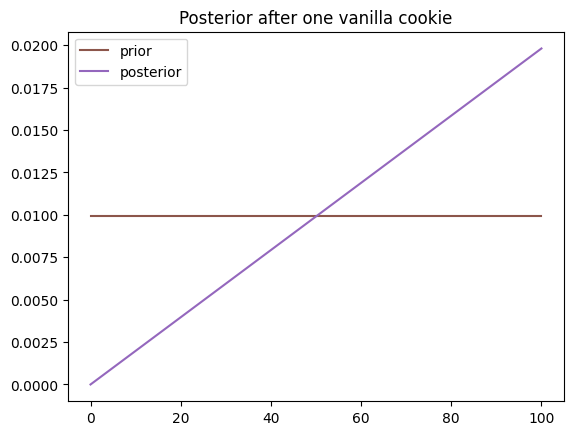

In [29]:
prior.plot(label='prior', color='C5')
posterior1.plot(label='posterior', color='C4', title='Posterior after one vanilla cookie').legend()

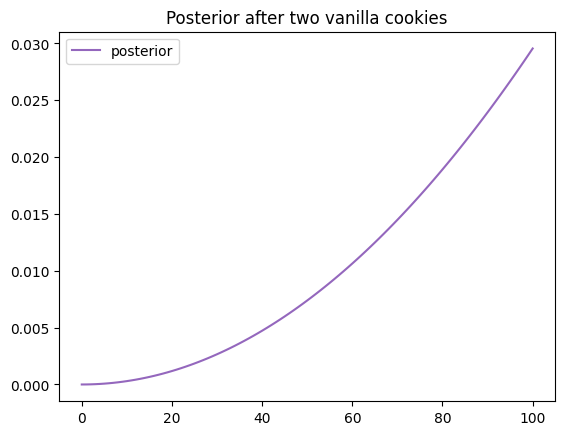

In [30]:
posterior2 = posterior1 * likelihood_vanilla
posterior2.normalize()
posterior2.plot(label='posterior', color='C4', title='Posterior after two vanilla cookies').legend()

67


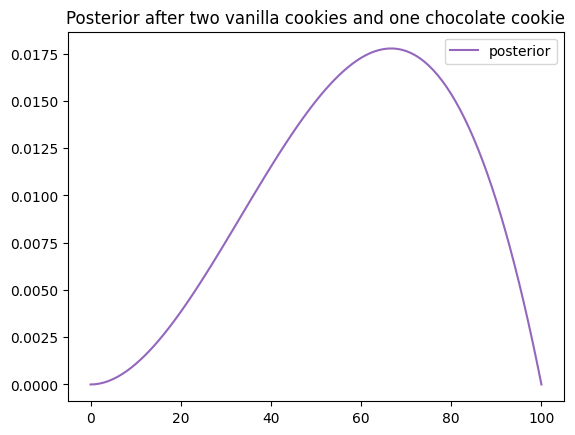

In [31]:
likelihood_chocolate = 1 - hypos/100

posterior3 = posterior2 * likelihood_chocolate
posterior3.normalize()
print(posterior3.max_prob())
posterior3.plot(label='posterior', color='C4', title='Posterior after two vanilla cookies and one chocolate cookie').legend()

## 3.5 The Dice Problem

In [33]:
hypos = [6, 8, 12]
prior = Pmf(1/3, index=hypos)

# got 1
likelihood = [1/6, 1/8, 1/12]
posterior = prior * likelihood
posterior.normalize()

# got 7
likelihood2 = [0, 1/8, 1/12]
posterior2 = posterior * likelihood2
posterior2.normalize()

posterior2

,probs
6,0.000000
8,0.692308
12,0.307692


## 3.6 Updating Dice

In [34]:
def update_dice(pmf, outcome):
    """Update pmf based on new outcome of dice roll."""
    pmf = pmf.copy()

    hypos = pmf.qs
    likelihood = 1 / hypos
    impossible = (outcome > hypos)
    likelihood[impossible] = 0
    
    pmf *= likelihood
    pmf.normalize()
    
    return pmf

posterior1 = update_dice(prior, 1)
posterior2 = update_dice(posterior1, 7)
posterior2

,probs
6,0.000000
8,0.692308
12,0.307692


## 3.8 Exercises
### 3.8.1 Exercise 1 

In [35]:
hypos = [6, 8, 12]
prior = Pmf(1/3, index=hypos)

posterior1 = update_dice(prior, 1)
posterior2 = update_dice(posterior1, 3)
posterior3 = update_dice(posterior2, 5)
posterior4 = update_dice(posterior3, 7)
posterior4

,probs
6,0.000000
8,0.835052
12,0.164948


### 3.8.2 Exercise 2

In [36]:
prior = Pmf(
    index=[4, 6, 8, 12, 20],
    data=[1, 2, 3, 4, 5], 
)
prior.normalize()

posterior = update_dice(prior, 7)
posterior

,probs
4,0.000000
6,0.000000
8,0.391304
12,0.347826
20,0.260870


### 3.8.3 Exercise 3

In [ ]:
prior = Pmf(
    index=[1, 2],  # index of drawer
    data=[1/2, 1/2]  
)
likelihood = [2 * 1/4, 3 * 1/9]  # likelihood of getting a pair of socks from each drawer
posterior = prior * likelihood
posterior.normalize()

# given that we get a pair of socks 
# probability of they are from drawer 1 and they are white
posterior.loc[1] / 2

,probs
1,0.6
2,0.4


### 3.8.4 Exercise 4

In [38]:
prior = Pmf(
    index=['identical', 'fraternal'],
    data=[1/3, 2/3]
)

# likelihood of having a brother given each type of twinning
brother_likelihood = [1, 1/2]  

posterior = prior * brother_likelihood
posterior.normalize()
posterior

,probs
identical,0.5
fraternal,0.5
